<a href="https://colab.research.google.com/github/rtajeong/M3_2026/blob/main/lab46_opencv_obj_detect_rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  이미지 윤곽 추출
- findContours() 사용

- im-circle.png 파일을 upload 한다.

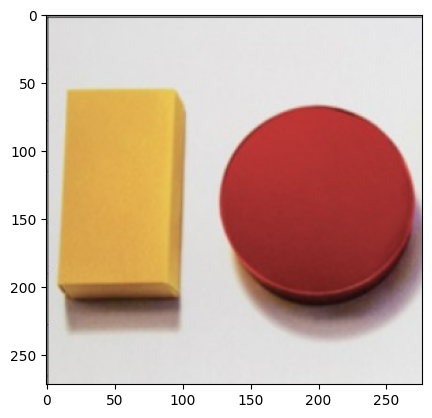

In [1]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("im-circle.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

## 윤곽선 추출
- 이미지를 그레이로 스케일링하고 블러 처리한다 (노이지를 없앰)
- 이미지를 흑백을 이진화 코딩한다 (threshold() 사용)
- findContour()로 경계를 검출한다

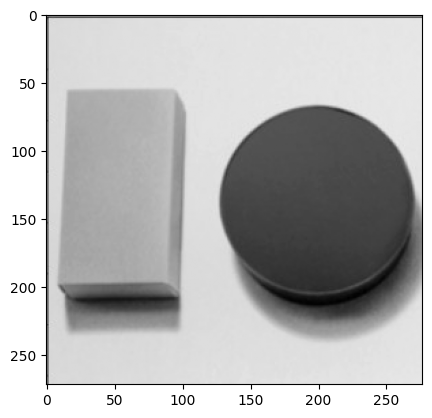

In [2]:
gray1 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray1, cmap="gray")

## findContours
- 인자는, 이미지, 검출모드, 윤곽추출방법이다.
- 리턴값은, 윤곽이미지, 윤곽리스트, 계층정보 3가지이다.
- LIST는 단순한 윤곽 검출을 한다

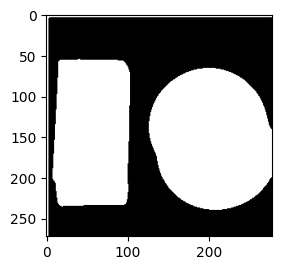

In [3]:
# 필터 크기는 홀수로 지정한다, 표준편차는 0으로 지정하면 자동으로 생성한다
gray2 = cv2.GaussianBlur(gray1, (7, 7), 0)
# 흑백으로 만든다, 임계값, 임계값을 넘었을 때 적용할 대체값, thresholding type
gray3 = cv2.threshold(gray2, 200, 255, cv2.THRESH_BINARY_INV)[1]

# 변환한 이미지 출력하기
plt.subplot(1, 2, 1)
plt.imshow(gray3, cmap="gray")


In [4]:
# 윤곽 검출하기 (contour 를 찾는 방법, 찾을 때 사용하는 근사치)
cnts = cv2.findContours(gray3,
                        cv2.RETR_LIST,
                        cv2.CHAIN_APPROX_SIMPLE)[0]
print (len(cnts))


3


126 66 151 174
8 55 95 181
0 0 277 272


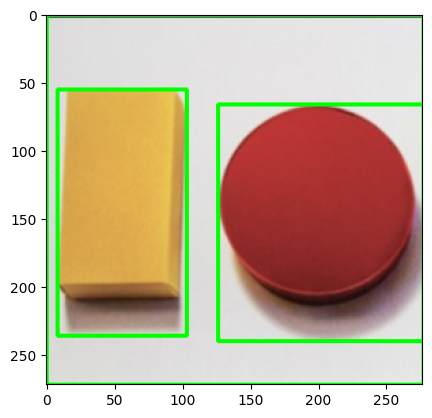

In [5]:
for c in cnts:

    x, y, w, h = cv2.boundingRect(c)  # create an approximate rectangle
    print(x,y,w,h)

    # 너무 크거나 너무 작은 부분 제거
    if h < 30 or h > 300 : continue

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [6]:
len(cnts)

3

## 우편번호 읽기
- cv2.threshold():
 - src: input image로 single-channel 이미지.(grayscale 이미지)
 - thresh: 임계값
 - maxval: 임계값을 넘었을 때 적용할 value
 - type: thresholding type
- cv2.findCountours():
 - finding contours is like finding white object from black background. So remember, object to be found should be white and background should be black.

- im-hagaki1.png 파일을 만든다. (기존의 이미지 링크가 더 이상 존재하지 않음)

In [41]:
import cv2
import numpy as np

# 1. 기존 코드 규격(w가 50~70 사이, 임계값 127)에 완벽히 매칭되는 백지 생성
# 가로 650, 세로 450 크기의 순백색 배경
img = np.zeros((450, 650, 3), dtype=np.uint8) + 255

# 가로 폭을 조건의 정중앙인 '60 픽셀'로 강제 고정
box_w = 60
box_h = 60
start_x = 45
start_y = 80
gap = 15

# 그레이스케일 변환 시 임계값 127에 확실히 걸리도록 짙은 빨간색 적용
red_color = (40, 40, 240)

# 앞 3자리 빨간 사각형 및 숫자 배치
for i in range(3):
    x1 = start_x + i * (box_w + gap)
    y1 = start_y
    x2 = x1 + box_w
    y2 = y1 + box_h
    cv2.rectangle(img, (x1, y1), (x2, y2), red_color, 3)
    cv2.putText(img, str(i+1), (x1+18, y1+45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 3)

# 뒤 4자리 빨간 사각형 및 숫자 배치
start_x_back = start_x + 3 * (box_w + gap) + 25
for i in range(4):
    x1 = start_x_back + i * (box_w + gap)
    y1 = start_y
    x2 = x1 + box_w
    y2 = y1 + box_h
    cv2.rectangle(img, (x1, y1), (x2, y2), red_color, 3)
    cv2.putText(img, str(i+4), (x1+18, y1+45), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 3)

# 2. 기존 코드가 읽어갈 파일명인 'im-hagaki1.png'로 로컬 저장
cv2.imwrite('im-hagaki1.png', img)
print("성공: 기존 코드 수치에 100% 매칭되는 'im-hagaki1.png' 파일이 생성되었다.")

성공: 기존 코드 수치에 100% 매칭되는 'im-hagaki1.png' 파일이 생성되었다.


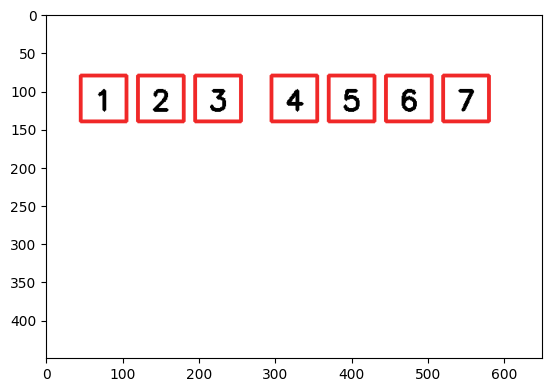

In [42]:
img_org = cv2.imread("im-hagaki1.png")
plt.imshow(cv2.cvtColor(img_org, cv2.COLOR_BGR2RGB))

In [43]:
def detect_zipno(fname):
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    im2 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)[1] # if pixel > 140, use 0,
                                                                  # else use 255
    plt.imshow(cv2.cvtColor(im2, cv2.COLOR_BGR2RGB))

    # 윤곽 검출
    cnts = cv2.findContours(im2,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE)[0]

    result = []
    for pt in cnts:
        x, y, w, h = cv2.boundingRect(pt)  # find retangles
        if not(50 < w < 70): continue
        result.append([x, y, w, h])
    # 추출한 윤곽을 위치에 따라 정렬
    result = sorted(result, key=lambda x: x[0])
    # 추출한 윤곽이 너무 가까운 것 제거하기
    result2 = []
    lastx = -100
    for x, y, w, h in result:
        if (x - lastx) < 10: continue
        result2.append([x, y, w, h])
        lastx = x
    # 테두리 출력하기
    for x, y, w, h in result2:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
    return result2, img

7


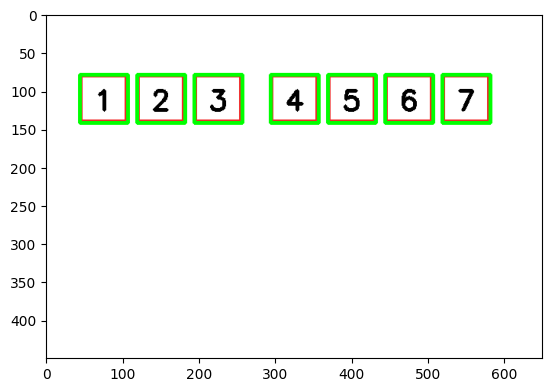

In [44]:
cnts, img = detect_zipno("im-hagaki1.png")
print(len(cnts))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

- you need to upload the model trained in the previous lab (lab45)

7

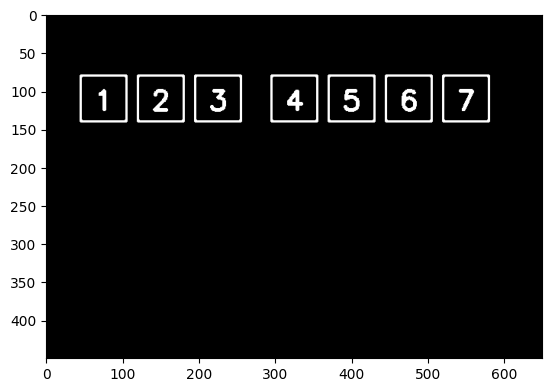

In [45]:
cnts, img = detect_zipno("im-hagaki1.png")
len(cnts)

number of detected objects: 7
the first one is in [44, 79, 63, 63].


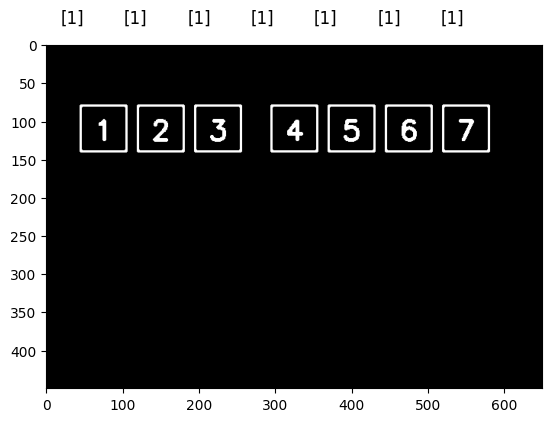

In [46]:
# for the model 'digits.pkl' - 성능이 매우 좋지 않음.
import joblib
clf = joblib.load("digits.pkl")

cnts, img = detect_zipno("im-hagaki1.png")
print(f'number of detected objects: {len(cnts)}')
print(f'the first one is in {cnts[0]}.')

for i, pt in enumerate(cnts):
    x, y, w, h = pt
    # im2 = img[y:y+h, x:x+w]
    im2 = img[y+5:y+h-5, x+5:x+w-5]  # 약간의 패딩을 주어 테두리 선이 숫자에 겹치지 않게 조절

    im2gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY) # 그레이스케일

    im2gray = cv2.resize(im2gray, (8, 8))
    resized = cv2.resize(im2gray, (8, 8)) # 크기 변경

    # resized = 16 - resized                # 흑백 반전
    im2gray = resized.reshape((-1, 64))   # 차원 변환
    res = clf.predict(im2gray)

    plt.subplot(1, len(cnts)+1, i + 1)
    # plt.imshow(im2)
    plt.axis("off")
    plt.title(res)

plt.show()

number of detected objects: 7
the first one is in [44, 79, 63, 63].


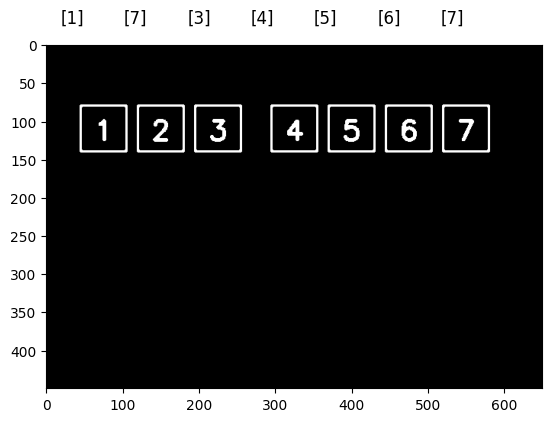

In [47]:
# for the model 'digits2.pkl'

import joblib
clf = joblib.load("digits2.pkl")

cnts, img = detect_zipno("im-hagaki1.png")
print(f'number of detected objects: {len(cnts)}')
print(f'the first one is in {cnts[0]}.')

for i, pt in enumerate(cnts):
    x, y, w, h = pt
    im2 = img[y+5:y+h-5, x+5:x+w-5]  # 약간의 패딩을 주어 테두리 선이 숫자에 겹치지 않게 조절

    im2gray = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY) # 그레이스케일
    resized = cv2.resize(im2gray, (28, 28))
    resized = 255 - resized                # 흑백 반전
    im2gray = resized.reshape((-1, 784))
    res = clf.predict(im2gray)

    plt.subplot(1, len(cnts)+1, i + 1)
    # plt.imshow(im2)
    plt.axis("off")
    plt.title(res)

plt.show()

---------------------------